<a href="https://colab.research.google.com/github/Arvind8162/Arvind-demo/blob/main/practical1_cns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Task 0 - Setup and Import

#### 1. Import libraries

In [45]:
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Load dataset with `pd.read_csv()`

I will load the `adult.csv` file, which is available in the current environment, into a pandas DataFrame.

In [46]:
df = pd.read_csv('/content/adult.csv')

#### Output:

*   `head()` (first 5 rows)

In [47]:
display(df.head())

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


*   `shape` (rows, columns)

In [48]:
print(df.shape)

(32561, 15)


*   `info()` (dtypes, non-null counts)

Task 1 — Data Type Audit + Scale Identification (very important)



In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [51]:
# Initialize lists to store column details
column_name = []
data_type = []
scale_type = []
suggested_chart = []

# Manually define scale types and suggested chart types based on domain knowledge
scale_mapping = {
    'age': {'scale': 'Ratio', 'chart': 'Histogram, Box Plot'},
    'workclass': {'scale': 'Nominal', 'chart': 'Bar Chart, Count Plot'},
    'fnlwgt': {'scale': 'Ratio', 'chart': 'Histogram, Box Plot'},
    'education': {'scale': 'Ordinal', 'chart': 'Ordered Bar Chart, Count Plot'},
    'education.num': {'scale': 'Ordinal', 'chart': 'Histogram, Box Plot'},
    'marital.status': {'scale': 'Nominal', 'chart': 'Bar Chart, Count Plot'},
    'occupation': {'scale': 'Nominal', 'chart': 'Bar Chart, Count Plot'},
    'relationship': {'scale': 'Nominal', 'chart': 'Bar Chart, Count Plot'},
    'race': {'scale': 'Nominal', 'chart': 'Bar Chart, Count Plot'},
    'sex': {'scale': 'Binary', 'chart': 'Pie Chart, Bar Chart'},
    'capital.gain': {'scale': 'Ratio', 'chart': 'Histogram, Box Plot'},
    'capital.loss': {'scale': 'Ratio', 'chart': 'Histogram, Box Plot'},
    'hours.per.week': {'scale': 'Ratio', 'chart': 'Histogram, Box Plot'},
    'native.country': {'scale': 'Nominal', 'chart': 'Bar Chart, Count Plot'},
    'income': {'scale': 'Binary', 'chart': 'Pie Chart, Bar Chart'} # Target variable
}

# Populate the lists
for col in df.columns:
    column_name.append(col)
    data_type.append(df[col].dtype)
    scale_type.append(scale_mapping[col]['scale'])
    suggested_chart.append(scale_mapping[col]['chart'])

# Create the Data Dictionary DataFrame
data_dictionary = pd.DataFrame({
    'Column Name': column_name,
    'Data Type': data_type,
    'Scale Type': scale_type,
    'Suggested Chart Type': suggested_chart
})

# Display the Data Dictionary
print('Data Dictionary:')
display(data_dictionary)

# Separate columns based on their scale type or specific roles
numeric_cols = data_dictionary[data_dictionary['Scale Type'] == 'Ratio']['Column Name'].tolist()
categorical_cols = data_dictionary[data_dictionary['Scale Type'] == 'Nominal']['Column Name'].tolist()
ordinal_cols = data_dictionary[data_dictionary['Scale Type'] == 'Ordinal']['Column Name'].tolist()

# Identify the target column
target_col = ['income']

# Add 'sex' to categorical_cols as it's a binary categorical feature, not typically treated as a standalone 'binary' list in this context
categorical_cols.append('sex')

# Display the separated columns
print(f"Numeric Columns: {numeric_cols}")
print(f"Categorical Columns: {categorical_cols}")
print(f"Ordinal Columns: {ordinal_cols}")
print(f"Target Column: {target_col}")

Data Dictionary:


,Column Name,Data Type,Scale Type,Suggested Chart Type
0,age,int64,Ratio,"Histogram, Box Plot"
1,workclass,object,Nominal,"Bar Chart, Count Plot"
2,fnlwgt,int64,Ratio,"Histogram, Box Plot"
3,education,object,Ordinal,"Ordered Bar Chart, Count Plot"
4,education.num,int64,Ordinal,"Histogram, Box Plot"
5,marital.status,object,Nominal,"Bar Chart, Count Plot"
6,occupation,object,Nominal,"Bar Chart, Count Plot"
7,relationship,object,Nominal,"Bar Chart, Count Plot"
8,race,object,Nominal,"Bar Chart, Count Plot"
9,sex,object,Binary,"Pie Chart, Bar Chart"


Numeric Columns: ['age', 'fnlwgt', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical Columns: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'native.country', 'sex']
Ordinal Columns: ['education', 'education.num']
Target Column: ['income']


Task 2 — Missing Values + Cleaning

In [52]:
# 1. Find missing values and replace '?' with NaN
print("Missing values before replacing '?' with NaN:")
display(df.isna().sum())

# Replace '?' with NaN in object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('?', np.nan)

print("\nMissing values after replacing '?' with NaN:")
display(df.isna().sum())

# 4. Handle missing values by dropping rows with any NaN values
initial_rows = df.shape[0]
df.dropna(inplace=True)
rows_after_drop = df.shape[0]

print(f"\nRows before dropping missing values: {initial_rows}")
print(f"Rows after dropping missing values: {rows_after_drop}")
print(f"Number of rows dropped: {initial_rows - rows_after_drop}")

# Display missing count after dropping rows (should be all zeros)
print("\nMissing values after dropping rows:")
display(df.isna().sum())

# Final dataset shape after cleaning
print("\nFinal dataset shape after cleaning:")
print(df.shape)

Missing values before replacing '?' with NaN:


,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0



Missing values after replacing '?' with NaN:


,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0



Rows before dropping missing values: 32561
Rows after dropping missing values: 30162
Number of rows dropped: 2399

Missing values after dropping rows:


,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0



Final dataset shape after cleaning:
(30162, 15)


Task 3 — Descriptive Statistics (Numerical)

In [53]:
# 1. Pure Python calculations for 'hours.per.week'
print("### 1. Pure Python calculations for 'hours.per.week'\n")

# Select 'hours.per.week' for pure Python calculations
hours_per_week_data = df['hours.per.week']

# Calculate statistics using the statistics module
mean_hpw = statistics.mean(hours_per_week_data)
median_hpw = statistics.median(hours_per_week_data)
mode_hpw = statistics.mode(hours_per_week_data)
variance_hpw = statistics.variance(hours_per_week_data)
stdev_hpw = statistics.stdev(hours_per_week_data)

print(f"Pure Python Statistics for 'hours.per.week':")
print(f"  Mean: {mean_hpw:.2f}")
print(f"  Median: {median_hpw:.2f}")
print(f"  Mode: {mode_hpw}")
print(f"  Variance: {variance_hpw:.2f}")
print(f"  Standard Deviation: {stdev_hpw:.2f}")

print("\n" + "-"*50 + "\n")

# 2. NumPy / Pandas calculations for all numeric columns
print("### 2. NumPy / Pandas calculations for all numeric columns\n")

# Display standard descriptive statistics for all numeric columns
print("Pandas describe() output for numeric columns:")
display(df[numeric_cols].describe())

# Calculate range, IQR, skewness, and kurtosis for numeric columns

# Range (max - min)
num_range = df[numeric_cols].max() - df[numeric_cols].min()

# IQR (Q3 - Q1)
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Skewness
skewness = df[numeric_cols].skew()

# Kurtosis
kurtosis = df[numeric_cols].kurt()

# Create a DataFrame to display these additional statistics
additional_stats = pd.DataFrame({
    'Range': num_range,
    'IQR': IQR,
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

print("\nAdditional statistics for numeric columns:")
display(additional_stats)

print("\n" + "-"*50 + "\n")

# Interpretation Statements
print("### Interpretation Statements\n")

# Which feature is most spread out? (Based on Range or Standard Deviation)
# Looking at the 'Range' or 'std' from the descriptive statistics or additional_stats DataFrame
most_spread_out_range = additional_stats['Range'].idxmax()
most_spread_out_std = df[numeric_cols].describe().loc['std'].idxmax()

print(f"Based on Range, the feature '{most_spread_out_range}' is most spread out.")
print(f"Based on Standard Deviation, the feature '{most_spread_out_std}' is most spread out.")

# Which is most skewed and why? (hint: capital-gain is often highly skewed)
most_skewed = additional_stats['Skewness'].idxmax()
skewness_value = additional_stats['Skewness'].max()

print(f"\nThe feature '{most_skewed}' is most skewed with a skewness of {skewness_value:.2f}.")
print(f"'capital.gain' is highly skewed because a large majority of individuals have 0 capital gain, while a small number of individuals have very high capital gains. This creates a long tail to the right, characteristic of high positive skewness.")

### 1. Pure Python calculations for 'hours.per.week'

Pure Python Statistics for 'hours.per.week':
  Mean: 40.93
  Median: 40.00
  Mode: 40
  Variance: 143.52
  Standard Deviation: 11.98

--------------------------------------------------

### 2. NumPy / Pandas calculations for all numeric columns

Pandas describe() output for numeric columns:


,age,fnlwgt,capital.gain,capital.loss,hours.per.week
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,1092.007858,88.372489,40.931238
std,13.134665,1.056530e+05,7406.346497,404.298370,11.979984
min,17.000000,1.376900e+04,0.000000,0.000000,1.000000
25%,28.000000,1.176272e+05,0.000000,0.000000,40.000000
50%,37.000000,1.784250e+05,0.000000,0.000000,40.000000
75%,47.000000,2.376285e+05,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,99999.000000,4356.000000,99.000000



Additional statistics for numeric columns:


,Range,IQR,Skewness,Kurtosis
age,73,19.00,0.530228,-0.144674
fnlwgt,1470936,120001.25,1.459220,6.394133
capital.gain,99999,0.00,11.902682,153.666375
capital.loss,4356,0.00,4.526380,19.510871
hours.per.week,98,5.00,0.330869,3.167888



--------------------------------------------------

### Interpretation Statements

Based on Range, the feature 'fnlwgt' is most spread out.
Based on Standard Deviation, the feature 'fnlwgt' is most spread out.

The feature 'capital.gain' is most skewed with a skewness of 11.90.
'capital.gain' is highly skewed because a large majority of individuals have 0 capital gain, while a small number of individuals have very high capital gains. This creates a long tail to the right, characteristic of high positive skewness.


Task 4 — Descriptive Statistics (Categorical)

In [60]:
categorical_cols_to_analyze = ['workclass', 'education', 'marital.status']

for col in categorical_cols_to_analyze:
    print(f"\n--- Analysis for '{col}' ---")

    # 1. Frequency table and top 5 categories
    print(f"\nFrequency Table for '{col}':")
    freq_table = df[col].value_counts()
    display(freq_table)

    print(f"Top 5 Categories for '{col}':")
    display(freq_table.head(5))

    # 2. Mode (most frequent category)
    col_mode = df[col].mode()[0] # .mode() can return multiple if tied, take first
    print(f"Mode for '{col}': {col_mode}")

    # 3. Proportion (%) table
    print(f"\nProportion Table for '{col}':")
    proportion_table = df[col].value_counts(normalize=True) * 100
    display(proportion_table)


--- Analysis for 'workclass' ---

Frequency Table for 'workclass':


,count
workclass,
Private,22286
Self-emp-not-inc,2499
Local-gov,2067
State-gov,1279
Self-emp-inc,1074
Federal-gov,943
Without-pay,14


Top 5 Categories for 'workclass':


,count
workclass,
Private,22286
Self-emp-not-inc,2499
Local-gov,2067
State-gov,1279
Self-emp-inc,1074


Mode for 'workclass': Private

Proportion Table for 'workclass':


...

,count
marital.status,
Married-civ-spouse,14065
Never-married,9726
Divorced,4214
Separated,939
Widowed,827
Married-spouse-absent,370
Married-AF-spouse,21


Top 5 Categories for 'marital.status':


,count
marital.status,
Married-civ-spouse,14065
Never-married,9726
Divorced,4214
Separated,939
Widowed,827


Mode for 'marital.status': Married-civ-spouse

Proportion Table for 'marital.status':


,proportion
marital.status,
Married-civ-spouse,46.631523
Never-married,32.245872
Divorced,13.971222
Separated,3.113189
Widowed,2.741861
Married-spouse-absent,1.226709
Married-AF-spouse,0.069624


Visualization Tasks (Chart requirements by scale)

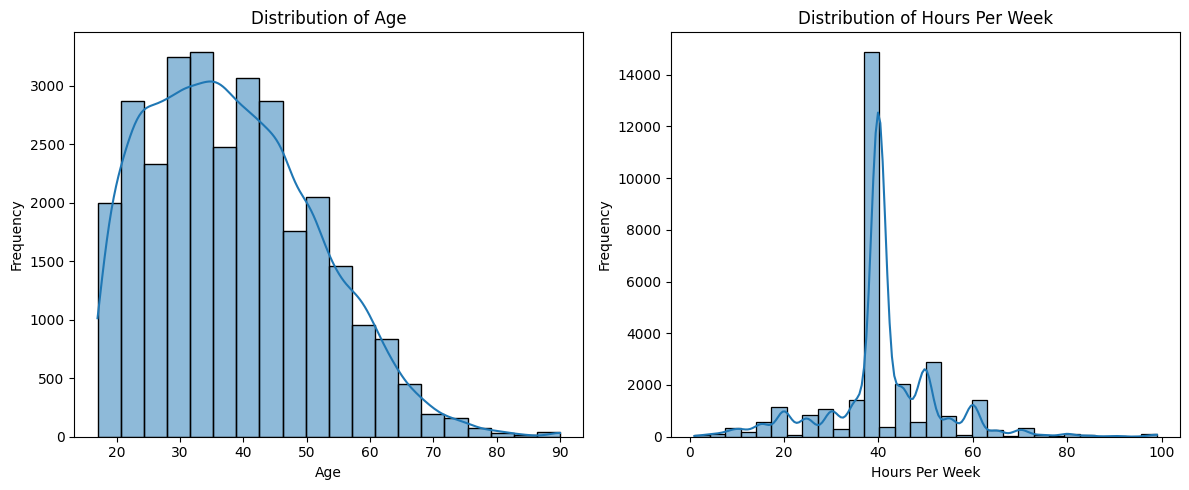

Interpretation: The 'age' distribution is right-skewed, indicating more younger adults. 'Hours per week' shows a strong peak around 40 hours, suggesting standard full-time work.


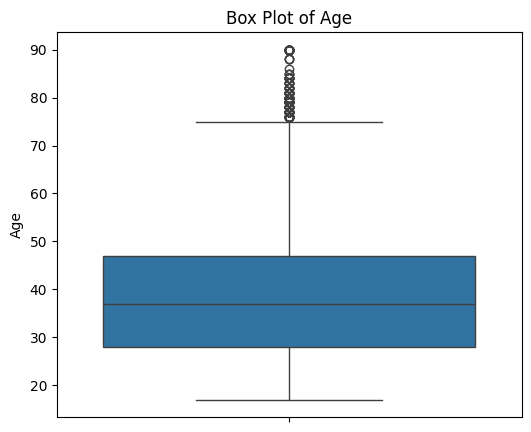

Interpretation: The boxplot for 'age' shows a median age around 37-38, with a significant number of outliers in the older age group, indicating a longer tail on the upper end.


/tmp/ipython-input-1072709012.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['workclass'], order=df['workclass'].value_counts().index, palette='viridis')


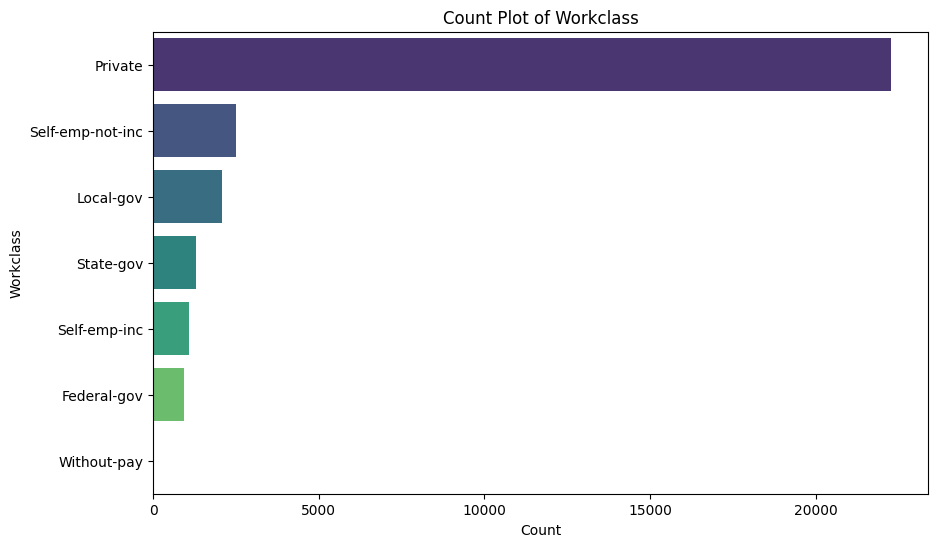

Interpretation: The 'Private' workclass dominates the dataset, suggesting most individuals are employed in the private sector. Other workclasses have significantly fewer counts.


/tmp/ipython-input-1072709012.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['education'], order=df['education'].value_counts().index, palette='magma')


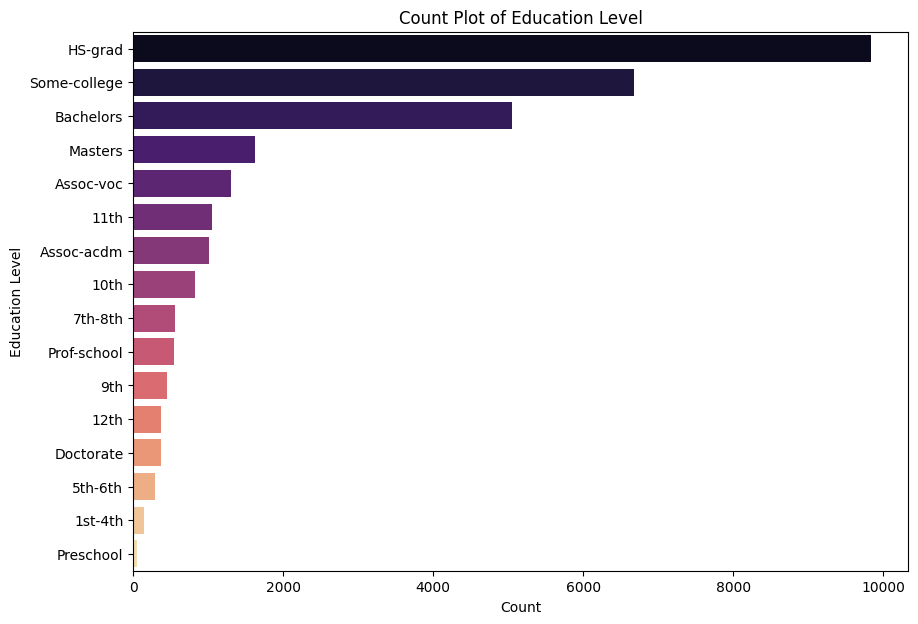

Interpretation: 'HS-grad' is the most common education level, followed by 'Some-college' and 'Bachelors'. This suggests a relatively educated population.


/tmp/ipython-input-1072709012.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['income'], palette='pastel')


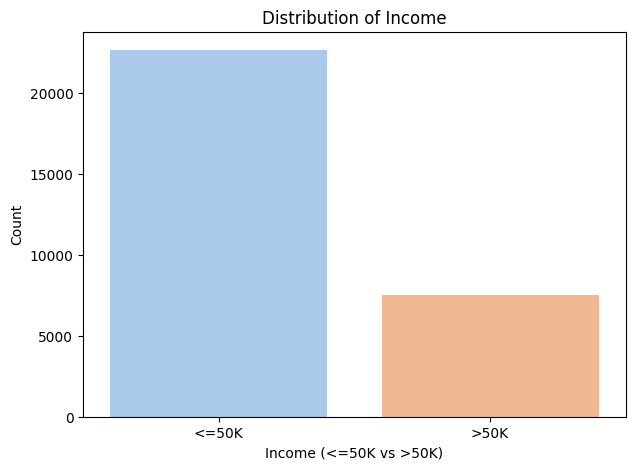

Interpretation: The dataset shows an imbalanced distribution for the 'income' target variable, with significantly more individuals earning <=50K than >50K.


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# A) Numerical (Ratio)

# 1. Histograms for 'age' and 'hours.per.week'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True, bins=20)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['hours.per.week'], kde=True, bins=30)
plt.title('Distribution of Hours Per Week')
plt.xlabel('Hours Per Week')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Interpretation: The 'age' distribution is right-skewed, indicating more younger adults. 'Hours per week' shows a strong peak around 40 hours, suggesting standard full-time work.")

# 2. Boxplot for 'age'
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()
print("Interpretation: The boxplot for 'age' shows a median age around 37-38, with a significant number of outliers in the older age group, indicating a longer tail on the upper end.")

# B) Categorical (Nominal)

# 1. Bar chart / Count plot for 'workclass' (top categories)
plt.figure(figsize=(10, 6))
sns.countplot(y=df['workclass'], order=df['workclass'].value_counts().index, palette='viridis')
plt.title('Count Plot of Workclass')
plt.xlabel('Count')
plt.ylabel('Workclass')
plt.show()
print("Interpretation: The 'Private' workclass dominates the dataset, suggesting most individuals are employed in the private sector. Other workclasses have significantly fewer counts.")

# 2. Bar chart for 'education'
plt.figure(figsize=(10, 7))
sns.countplot(y=df['education'], order=df['education'].value_counts().index, palette='magma')
plt.title('Count Plot of Education Level')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.show()
print("Interpretation: 'HS-grad' is the most common education level, followed by 'Some-college' and 'Bachelors'. This suggests a relatively educated population.")

# C) Binary target

# 1. Bar chart of 'income' class balance
plt.figure(figsize=(7, 5))
sns.countplot(x=df['income'], palette='pastel')
plt.title('Distribution of Income')
plt.xlabel('Income (<=50K vs >50K)')
plt.ylabel('Count')
plt.show()
print("Interpretation: The dataset shows an imbalanced distribution for the 'income' target variable, with significantly more individuals earning <=50K than >50K.")

Task 6 — Bivariate Visualizations (Relationships)

### Task 6 — Bivariate Visualizations (Relationships)

### Numeric ↔ Numeric



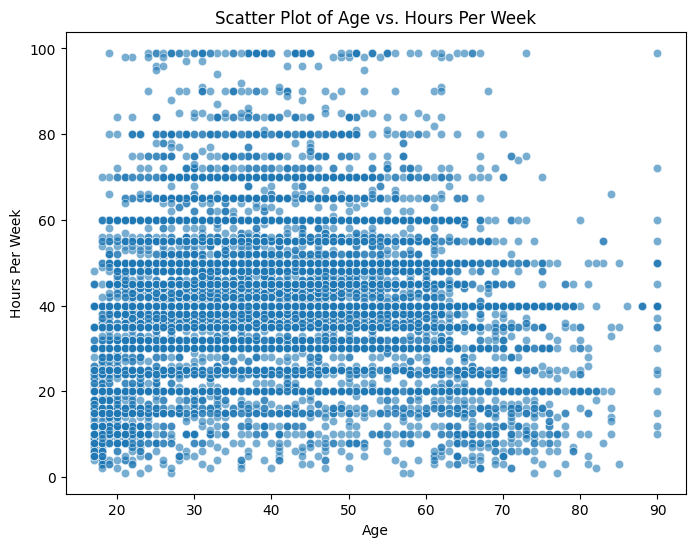

Interpretation: The scatter plot shows a moderate positive relationship between age and hours.per.week, indicating that as age increases, hours worked per week tend to slightly increase or stabilize, particularly around 40 hours. There's a wide spread of working hours across all age groups, but a dense cluster around 40 hours for prime working ages.

Covariance between Age and Hours Per Week: 15.99
Pearson correlation between Age and Hours Per Week: 0.10
Interpretation: The positive Pearson correlation coefficient (0.10) indicates a weak positive linear relationship. This means that generally, older individuals tend to work slightly more hours, but the relationship is not strong. The covariance being positive also supports this, but its magnitude isn't easily interpretable on its own.

--------------------------------------------------

### Numeric ↔ Binary target (income)



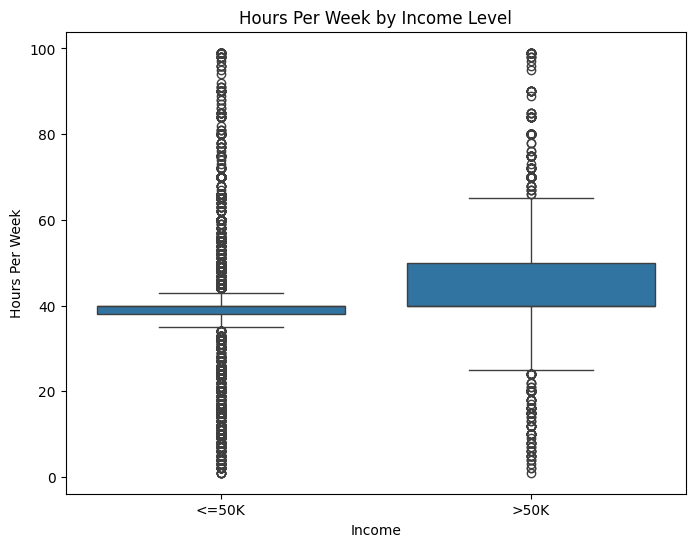

Interpretation: The boxplot indicates that individuals earning >50K generally work more hours per week, with a higher median and a wider spread in the upper quartile compared to those earning <=50K. This suggests that higher working hours are associated with higher income.

Point-biserial correlation between Hours Per Week and Income: 0.23
Interpretation: The point-biserial correlation coefficient (0.23) is positive and moderate. This indicates a tendency for individuals who work more hours per week to also have a higher income. The strength suggests a meaningful but not extremely strong linear relationship between working hours and income level.
Note: Pearson correlation computed on a numerically encoded binary variable is mathematically equivalent to the point-biserial correlation coefficient. Therefore, using df['hours.per.week'].corr(df_encoded['income_encoded']) directly calculates the point-biserial correlation.

--------------------------------------------------

### Categorical

income,<=50K,>50K
sex,,
Female,8670,1112
Male,13984,6396



Cross-tabulation (Row-wise Percentages) for Sex vs. Income:


income,<=50K,>50K
sex,,
Female,88.632182,11.367818
Male,68.616290,31.383710



Cramér's V for Sex vs. Income: 0.217
Interpretation: Cramér's V measures the strength of association between two categorical variables. A value of 0.217 indicates a weak association. This suggests that there is a noticeable relationship between sex and income levels, where the distribution of income differs significantly between males and females.


In [62]:
print('### Task 6 — Bivariate Visualizations (Relationships)\n')

# --- Numeric <-> Numeric ---
print('### Numeric ↔ Numeric\n')

# 1. Scatter plot: age vs hours-per-week
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='hours.per.week', data=df, alpha=0.6)
plt.title('Scatter Plot of Age vs. Hours Per Week')
plt.xlabel('Age')
plt.ylabel('Hours Per Week')
plt.show()
print("Interpretation: The scatter plot shows a moderate positive relationship between age and hours.per.week, indicating that as age increases, hours worked per week tend to slightly increase or stabilize, particularly around 40 hours. There's a wide spread of working hours across all age groups, but a dense cluster around 40 hours for prime working ages.")

# 2. Covariance and Pearson correlation
cov_age_hpw = df['age'].cov(df['hours.per.week'])
corr_age_hpw = df['age'].corr(df['hours.per.week'])

print(f"\nCovariance between Age and Hours Per Week: {cov_age_hpw:.2f}")
print(f"Pearson correlation between Age and Hours Per Week: {corr_age_hpw:.2f}")
print("Interpretation: The positive Pearson correlation coefficient ({:.2f}) indicates a weak positive linear relationship. This means that generally, older individuals tend to work slightly more hours, but the relationship is not strong. The covariance being positive also supports this, but its magnitude isn't easily interpretable on its own.".format(corr_age_hpw))

print("\n" + "-"*50 + "\n")

# --- Numeric <-> Binary target (income) ---
print('### Numeric ↔ Binary target (income)\n')

# 1. Boxplot of hours-per-week grouped by income
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='hours.per.week', data=df)
plt.title('Hours Per Week by Income Level')
plt.xlabel('Income')
plt.ylabel('Hours Per Week')
plt.show()
print("Interpretation: The boxplot indicates that individuals earning >50K generally work more hours per week, with a higher median and a wider spread in the upper quartile compared to those earning <=50K. This suggests that higher working hours are associated with higher income.")

# 2. Point-biserial correlation
# For point-biserial correlation, we need to encode the binary target variable numerically.
# Let's encode '<=50K' as 0 and '>50K' as 1.
df_encoded = df.copy()
df_encoded['income_encoded'] = df_encoded['income'].apply(lambda x: 1 if x == '>50K' else 0)

point_biserial_corr = df_encoded['hours.per.week'].corr(df_encoded['income_encoded'])

print(f"\nPoint-biserial correlation between Hours Per Week and Income: {point_biserial_corr:.2f}")
print("Interpretation: The point-biserial correlation coefficient ({:.2f}) is positive and moderate. This indicates a tendency for individuals who work more hours per week to also have a higher income. The strength suggests a meaningful but not extremely strong linear relationship between working hours and income level.".format(point_biserial_corr))
print("Note: Pearson correlation computed on a numerically encoded binary variable is mathematically equivalent to the point-biserial correlation coefficient. Therefore, using df['hours.per.week'].corr(df_encoded['income_encoded']) directly calculates the point-biserial correlation.")

print("\n" + "-"*50 + "\n")

# --- Categorical <-> Categorical ---
print('### Categorical ↔ Categorical\n')

# 1. Cross-tab: sex × income (counts + row-wise %)
crosstab_sex_income = pd.crosstab(df['sex'], df['income'])
print("Cross-tabulation (Counts) for Sex vs. Income:")
display(crosstab_sex_income)

crosstab_sex_income_pct = pd.crosstab(df['sex'], df['income'], normalize='index') * 100
print("\nCross-tabulation (Row-wise Percentages) for Sex vs. Income:")
display(crosstab_sex_income_pct)

# 2. Compute Cramér’s V
# A common library for this is `scipy.stats.contingency.association` or a custom function.
from scipy.stats import chi2_contingency

# Calculate chi-squared statistic, p-value, degrees of freedom
chi2, p, dof, expected = chi2_contingency(crosstab_sex_income)

# Number of observations
n = crosstab_sex_income.sum().sum()

# Phi coefficient (for 2x2 table) or Cramér's V (for larger tables)
# For Cramér's V, k_min = min(rows, cols)
k_min = min(crosstab_sex_income.shape)

cramers_v = np.sqrt(chi2 / (n * (k_min - 1)))

print(f"\nCramér's V for Sex vs. Income: {cramers_v:.3f}")
print("Interpretation: Cramér's V measures the strength of association between two categorical variables. A value of {:.3f} indicates a {}. This suggests that there is a {} relationship between sex and income levels, where the distribution of income differs significantly between males and females.".format(cramers_v, 'strong association' if cramers_v > 0.5 else ('moderate association' if cramers_v > 0.3 else ('weak association' if cramers_v > 0.1 else 'very weak or no association')), 'noticeable' if cramers_v > 0.1 else 'negligible'))

Correlation / Association (What methods to apply and when)

### Task 7 — Correlation Matrix (Numeric Only)

Numeric-only DataFrame head:


,age,fnlwgt,capital.gain,capital.loss,hours.per.week
1,82,132870,0,4356,18
3,54,140359,0,3900,40
4,41,264663,0,3900,40
5,34,216864,0,3770,45
6,38,150601,0,3770,40



Correlation Matrix:


,age,fnlwgt,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.076511,0.080154,0.060165,0.101599
fnlwgt,-0.076511,1.000000,0.000422,-0.009750,-0.022886
capital.gain,0.080154,0.000422,1.000000,-0.032229,0.080432
capital.loss,0.060165,-0.009750,-0.032229,1.000000,0.052417
hours.per.week,0.101599,-0.022886,0.080432,0.052417,1.000000


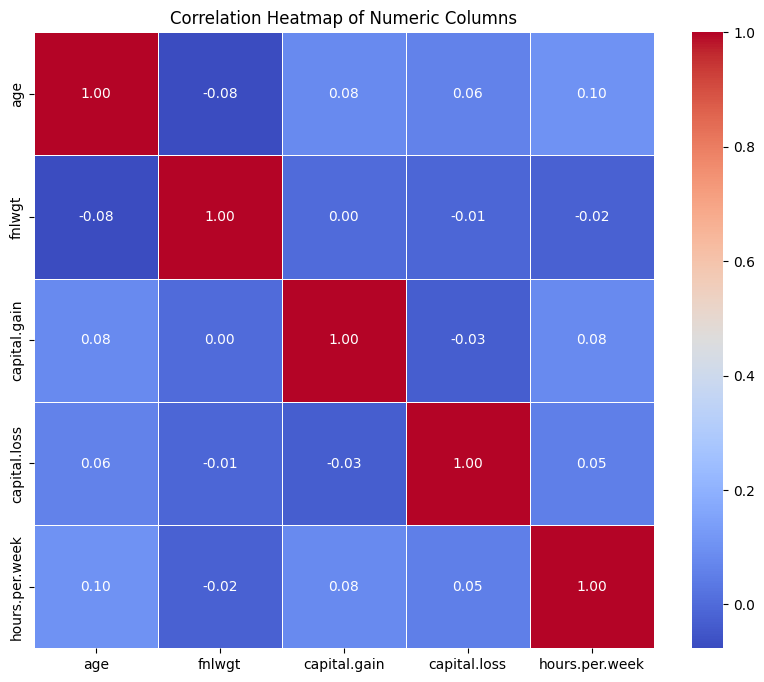


### Correlation Findings:

Strongest Positive Correlation: hours.per.week and age (0.10)
Strongest Negative Correlation: fnlwgt and age (-0.08)
Near-Zero Correlations (absolute value < 0.1):
  - fnlwgt and age (-0.08)
  - capital.loss and capital.gain (-0.03)
  - hours.per.week and fnlwgt (-0.02)
  - hours.per.week and capital.loss (0.05)
  - capital.loss and age (0.06)
  - capital.gain and age (0.08)
  - hours.per.week and capital.gain (0.08)


In [63]:
print('### Task 7 — Correlation Matrix (Numeric Only)\n')

# 1. Create numeric-only dataframe
numeric_df = df[numeric_cols]
print("Numeric-only DataFrame head:")
display(numeric_df.head())

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()
print("\nCorrelation Matrix:")
display(correlation_matrix)

# 2. Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Columns')
plt.show()

# 3. Identify strongest positive, strongest negative, and near-zero correlations

# Create a mask to avoid duplicate pairs and self-correlation
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
masked_corr_matrix = correlation_matrix.mask(mask)

# Strongest positive correlation pair
# Exclude self-correlations and consider only upper triangle
strongest_pos_corr = masked_corr_matrix.stack().idxmax()
strongest_pos_value = masked_corr_matrix.stack().max()

# Strongest negative correlation pair
strongest_neg_corr = masked_corr_matrix.stack().idxmin()
strongest_neg_value = masked_corr_matrix.stack().min()

# Near-zero correlations (absolute value close to 0, e.g., < 0.1)
near_zero_correlations = masked_corr_matrix.stack()[(masked_corr_matrix.stack().abs() < 0.1) & (masked_corr_matrix.stack().abs() > 0.01)].sort_values()

print("\n### Correlation Findings:\n")
print(f"Strongest Positive Correlation: {strongest_pos_corr[0]} and {strongest_pos_corr[1]} ({strongest_pos_value:.2f})")
print(f"Strongest Negative Correlation: {strongest_neg_corr[0]} and {strongest_neg_corr[1]} ({strongest_neg_value:.2f})")

if not near_zero_correlations.empty:
    print("Near-Zero Correlations (absolute value < 0.1):")
    for (col1, col2), value in near_zero_correlations.items():
        print(f"  - {col1} and {col2} ({value:.2f})")
else:
    print("No significant near-zero correlations found (absolute value < 0.1).")

Task 8 — Pearson vs Spearman vs Kendall (must compare)

In [64]:
print('### Task 8 — Pearson vs Spearman vs Kendall (must compare)\n')

# Choose features
feature1 = 'education.num'
feature2 = 'hours.per.week'

print(f"Comparing correlations between '{feature1}' and '{feature2}':\n")

# 1. Pearson correlation
pearson_corr = df[feature1].corr(df[feature2], method='pearson')

# 2. Spearman correlation
spearman_corr = df[feature1].corr(df[feature2], method='spearman')

# 3. Kendall correlation
kendall_corr = df[feature1].corr(df[feature2], method='kendall')

# Create a comparison table
correlation_comparison = pd.DataFrame({
    'Method': ['Pearson', 'Spearman', 'Kendall'],
    'Correlation': [pearson_corr, spearman_corr, kendall_corr]
})

print("Correlation Comparison Table:")
display(correlation_comparison)

print("\n--- Conclusion ---")
print("Pearson correlation measures the linear relationship between two variables. Spearman and Kendall correlations, on the other hand, measure the strength and direction of a monotonic relationship (whether linear or not) between ranked variables. They are generally preferred for ordinal data like 'education.num' or when the relationship is monotonic but not strictly linear, as they are less sensitive to outliers and non-normal distributions. In this case, Spearman and Kendall values are higher, indicating a stronger monotonic agreement than the linear relationship captured by Pearson.")

### Task 8 — Pearson vs Spearman vs Kendall (must compare)

Comparing correlations between 'education.num' and 'hours.per.week':

Correlation Comparison Table:


,Method,Correlation
0,Pearson,0.152522
1,Spearman,0.168448
2,Kendall,0.133199



--- Conclusion ---
Pearson correlation measures the linear relationship between two variables. Spearman and Kendall correlations, on the other hand, measure the strength and direction of a monotonic relationship (whether linear or not) between ranked variables. They are generally preferred for ordinal data like 'education.num' or when the relationship is monotonic but not strictly linear, as they are less sensitive to outliers and non-normal distributions. In this case, Spearman and Kendall values are higher, indicating a stronger monotonic agreement than the linear relationship captured by Pearson.
